

**NVIDIA's Stock Price Analysis & Prediction**

In [15]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score
from scipy import stats
import warnings
#Using this library to hide unnecessary warnings from external packages to keep the output clean
warnings.filterwarnings('ignore')

**Dataset Loading**

In [16]:
df = pd.read_csv(r'Z:\Downloads\FDS Final Project 2026\NVidia_stock_history.csv')
#renaming columns to lowercase so easier to type
df.columns = ['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume']

#conversion of date column to datetime format
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df

,date,adj_close,close,high,low,open,volume
0,1999-01-22,0.037603,0.041016,0.048828,0.038802,0.043750,2714688000
1,1999-01-25,0.041542,0.045313,0.045833,0.041016,0.044271,510480000
2,1999-01-26,0.038319,0.041797,0.046745,0.041146,0.045833,343200000
3,1999-01-27,0.038200,0.041667,0.042969,0.039583,0.041927,244368000
4,1999-01-28,0.038080,0.041536,0.041927,0.041276,0.041667,227520000
...,...,...,...,...,...,...,...
6842,2026-04-07,178.100006,178.100006,178.229996,173.660004,175.729996,132534900
6843,2026-04-08,182.080002,182.080002,185.259995,180.300003,184.500000,147732700
6844,2026-04-09,183.910004,183.910004,184.080002,180.619995,181.839996,116428500
6845,2026-04-10,188.630005,188.630005,190.000000,184.300003,184.309998,160099500


**Exploratory Data Analysis(EDA)**

In [17]:
# basic info about the dataset (lecture 02)
print('shape:', df.shape)
print('\ndata types:', df.dtypes)
print('\ndate range:', df['date'].min(), 'to', df['date'].max())

shape: (6847, 7)

data types: date         datetime64[ns]
adj_close           float64
close               float64
high                float64
low                 float64
open                float64
volume                int64
dtype: object

date range: 1999-01-22 00:00:00 to 2026-04-13 00:00:00


In [18]:
#missing values and duplicates
print(df.isnull().sum())
print('\nnumber of duplicate rows:', df.duplicated().sum())

date         0
adj_close    0
close        0
high         0
low          0
open         0
volume       0
dtype: int64

number of duplicate rows: 0


In [19]:
df.describe()

,date,adj_close,close,high,low,open,volume
count,6847,6847.000000,6847.000000,6847.000000,6847.000000,6847.000000,6.847000e+03
mean,2012-08-30 04:52:07.325836032,15.275748,15.305158,15.561350,15.028806,15.309164,5.824365e+08
min,1999-01-22 00:00:00,0.031276,0.034115,0.035547,0.033333,0.034896,1.968000e+07
25%,2005-11-09 12:00:00,0.264951,0.289000,0.295916,0.279750,0.288000,3.182060e+08
50%,2012-08-28 00:00:00,0.453142,0.485250,0.492500,0.477500,0.485000,4.837160e+08
75%,2019-06-19 12:00:00,5.909947,5.968000,6.048125,5.876375,5.955500,7.156820e+08
max,2026-04-13 00:00:00,207.017273,207.039993,212.190002,205.559998,208.080002,9.230856e+09
std,NaN,39.300687,39.302298,39.922591,38.650250,39.333641,4.292433e+08


**Data Preprocessing and Feature Engineering**

In [20]:
#feature engineering is used to create new columns from existing data
#daily return shows how much price changed in % each day
df['daily_return'] = ((df['close'] - df['open']) / df['open']) * 100
#price range = difference between highest and lowest price that day
df['price_range'] = df['high'] - df['low']

#7 day and 30 day moving average of close price
df['ma7']  = df['close'].rolling(window=7).mean()
df['ma30'] = df['close'].rolling(window=30).mean()

#drop_Na rows created by rolling window
df = df.dropna().reset_index(drop=True)
print('rows after cleaning:', len(df))

df.head()

rows after cleaning: 6818


,date,adj_close,close,high,low,open,volume,daily_return,price_range,ma7,ma30
0,1999-03-05,0.040229,0.043880,0.044010,0.041927,0.041927,78768000,4.658101,0.002083,0.044717,0.042379
1,1999-03-08,0.040825,0.044531,0.045833,0.041927,0.042708,75888000,4.268523,0.003906,0.044234,0.042496
2,1999-03-09,0.042139,0.045964,0.046615,0.044401,0.044401,143184000,3.520186,0.002214,0.044271,0.042517
3,1999-03-10,0.041422,0.045182,0.046615,0.044531,0.046615,235344000,-3.074118,0.002084,0.044159,0.042630
4,1999-03-11,0.039632,0.043229,0.045182,0.043229,0.044401,54288000,-2.639586,0.001953,0.043824,0.042682


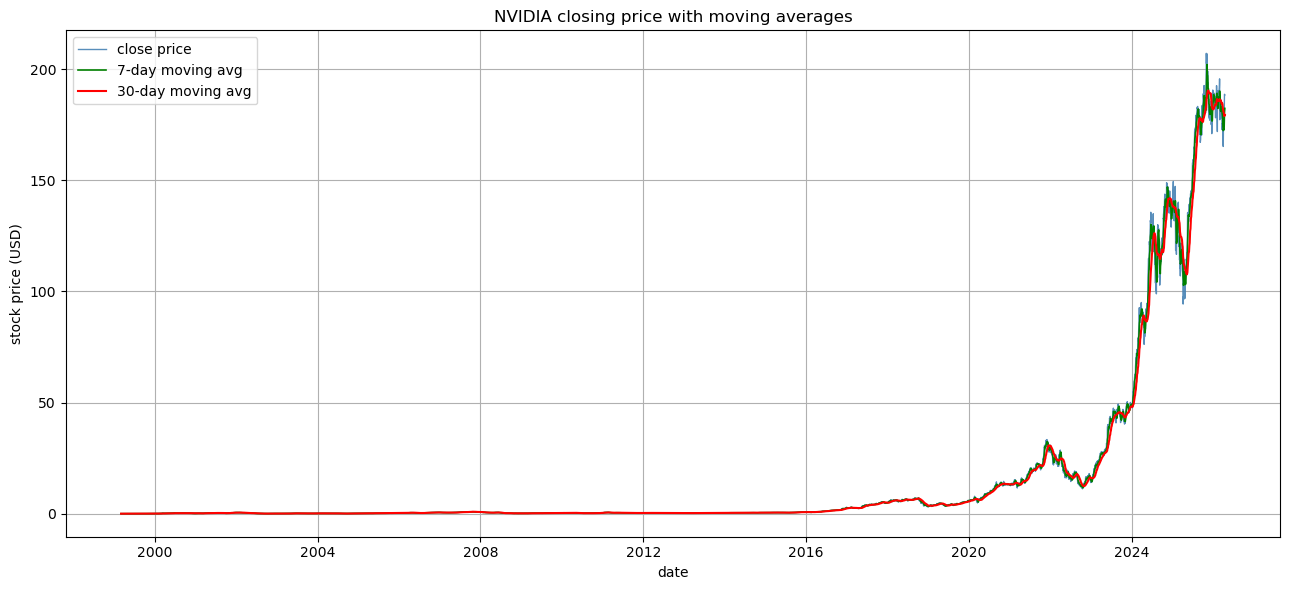

In [21]:
# plot closing price over time with moving averages
plt.figure(figsize=(13, 6))
plt.plot(df['date'], df['close'], color='steelblue', linewidth=1, label='close price', alpha=0.9)
plt.plot(df['date'], df['ma7'],  color='green',    linewidth=1.2, label='7-day moving avg')
plt.plot(df['date'], df['ma30'], color='red',       linewidth=1.5, label='30-day moving avg')
plt.xlabel('date')
plt.ylabel('stock price (USD)')
plt.title('NVIDIA closing price with moving averages')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

Plotting open high low close prices together

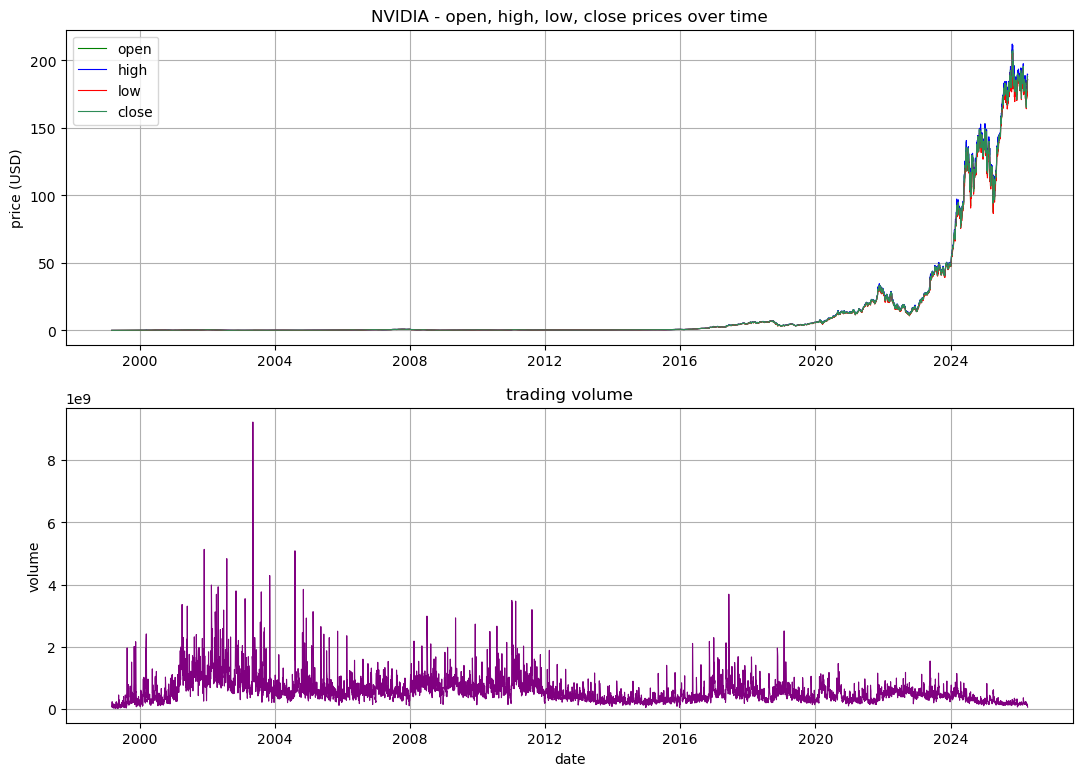

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
axes[0].plot(df['date'], df['open'],  label='open',  color='green',     linewidth=0.8)
axes[0].plot(df['date'], df['high'],  label='high',  color='blue',  linewidth=0.8)
axes[0].plot(df['date'], df['low'],   label='low',   color='red',    linewidth=0.8)
axes[0].plot(df['date'], df['close'], label='close', color='seagreen', linewidth=0.8)
axes[0].set_ylabel('price (USD)')
axes[0].set_title('NVIDIA - open, high, low, close prices over time')
axes[0].legend()
axes[0].grid()

axes[1].plot(df['date'], df['volume'], color='purple', linewidth=0.8)
axes[1].set_ylabel('volume')
axes[1].set_xlabel('date')
axes[1].set_title('trading volume')
axes[1].grid()
plt.show()

**Statistics and Probability**

In [23]:
print('mean daily return   :', round(df['daily_return'].mean(), 4), '%')
print('std deviation       :', round(df['daily_return'].std(), 4), '%')
print('skewness            :', round(df['daily_return'].skew(), 4))
print('kurtosis            :', round(df['daily_return'].kurtosis(), 4))
print('min return          :', round(df['daily_return'].min(), 4), '%')
print('max return          :', round(df['daily_return'].max(), 4), '%')

#shapiro-wilk test for normality
shapiro_stat, shapiro_p = stats.shapiro(df['daily_return'].sample(min(5000, len(df))))
print('\nshapiro-wilk p-value:', round(shapiro_p, 6))
if shapiro_p < 0.05:
    print('daily returns are NOT normally distributed')
else:
    print('daily returns follow normal distribution')

mean daily return   : 0.0465 %
std deviation       : 3.1599 %
skewness            : 0.7767
kurtosis            : 9.7822
min return          : -25.8106 %
max return          : 39.486 %

shapiro-wilk p-value: 0.0
daily returns are NOT normally distributed


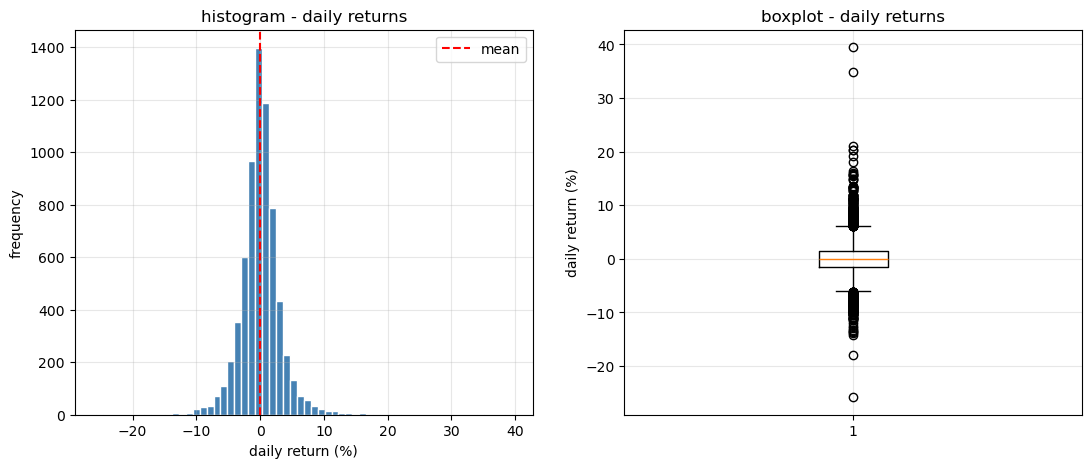

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
#Histogram used to show distribution of daily returns
axes[0].hist(df['daily_return'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(df['daily_return'].mean(), color='red', linestyle='--', label='mean')
axes[0].set_title('histogram - daily returns')
axes[0].set_xlabel('daily return (%)')
axes[0].set_ylabel('frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

#boxplot shows variance, median and outliers 
axes[1].boxplot(df['daily_return'], vert=True)
axes[1].set_title('boxplot - daily returns')
axes[1].set_ylabel('daily return (%)')
axes[1].grid(alpha=0.3)
plt.show()

In [25]:
#confidence interval and probability
mean_ret = df['daily_return'].mean()
std_ret  = df['daily_return'].std()
n        = len(df)

margin = 1.96 * (std_ret / np.sqrt(n))
print('mean daily return        :', round(mean_ret, 4), '%')
print('95% confidence interval  : (', round(mean_ret - margin, 4), ',', round(mean_ret + margin, 4), ')')

#probability that the stock gives a positive return on any given day
z_score = (0 - mean_ret) / std_ret
prob_positive = 1 - stats.norm.cdf(z_score)

print('\nprobability of positive return on any day:', round(prob_positive * 100, 2), '%')

mean daily return        : 0.0465 %
95% confidence interval  : ( -0.0285 , 0.1215 )

probability of positive return on any day: 50.59 %


**Correlation Analysis**

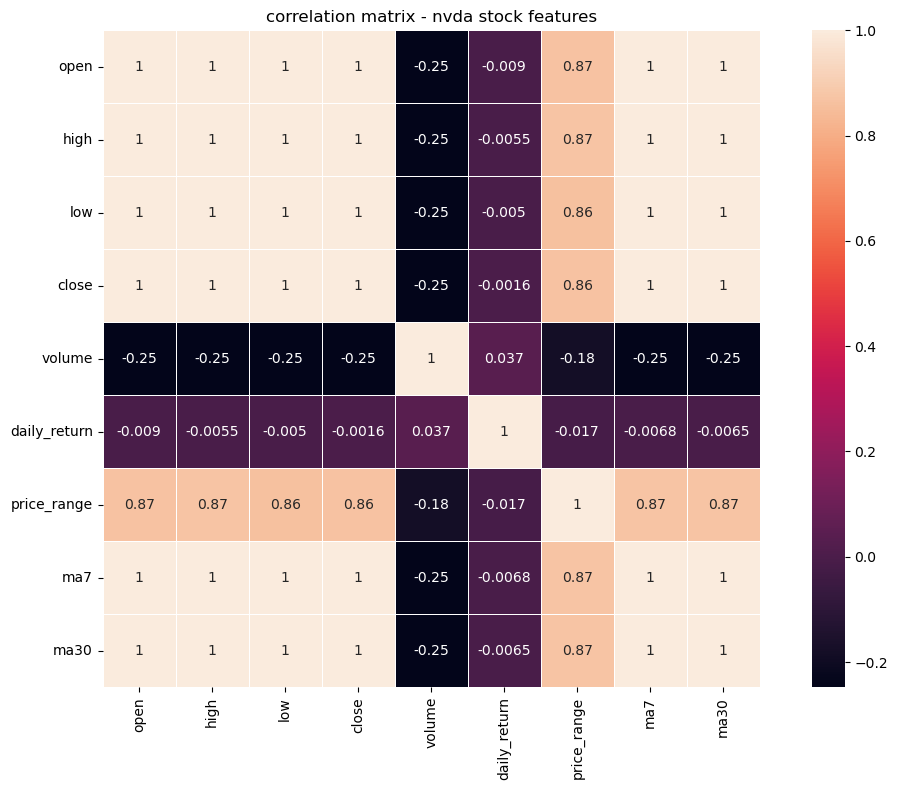

In [26]:
#corr matrix shows how strongly each column is related to the others
corr_cols = ['open', 'high', 'low', 'close', 'volume', 'daily_return', 'price_range', 'ma7', 'ma30']
corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, linewidths=0.5, square=True)
plt.title('correlation matrix - nvda stock features')
plt.tight_layout()
plt.show()

In [27]:
#checking which features are most correlated with close price
print('correlation of features with close price (sorted):')
print(corr_matrix['close'].drop('close').sort_values(ascending=False))

correlation of features with close price (sorted):
low             0.999879
high            0.999857
open            0.999701
ma7             0.999290
ma30            0.997131
price_range     0.863561
daily_return   -0.001630
volume         -0.247519
Name: close, dtype: float64


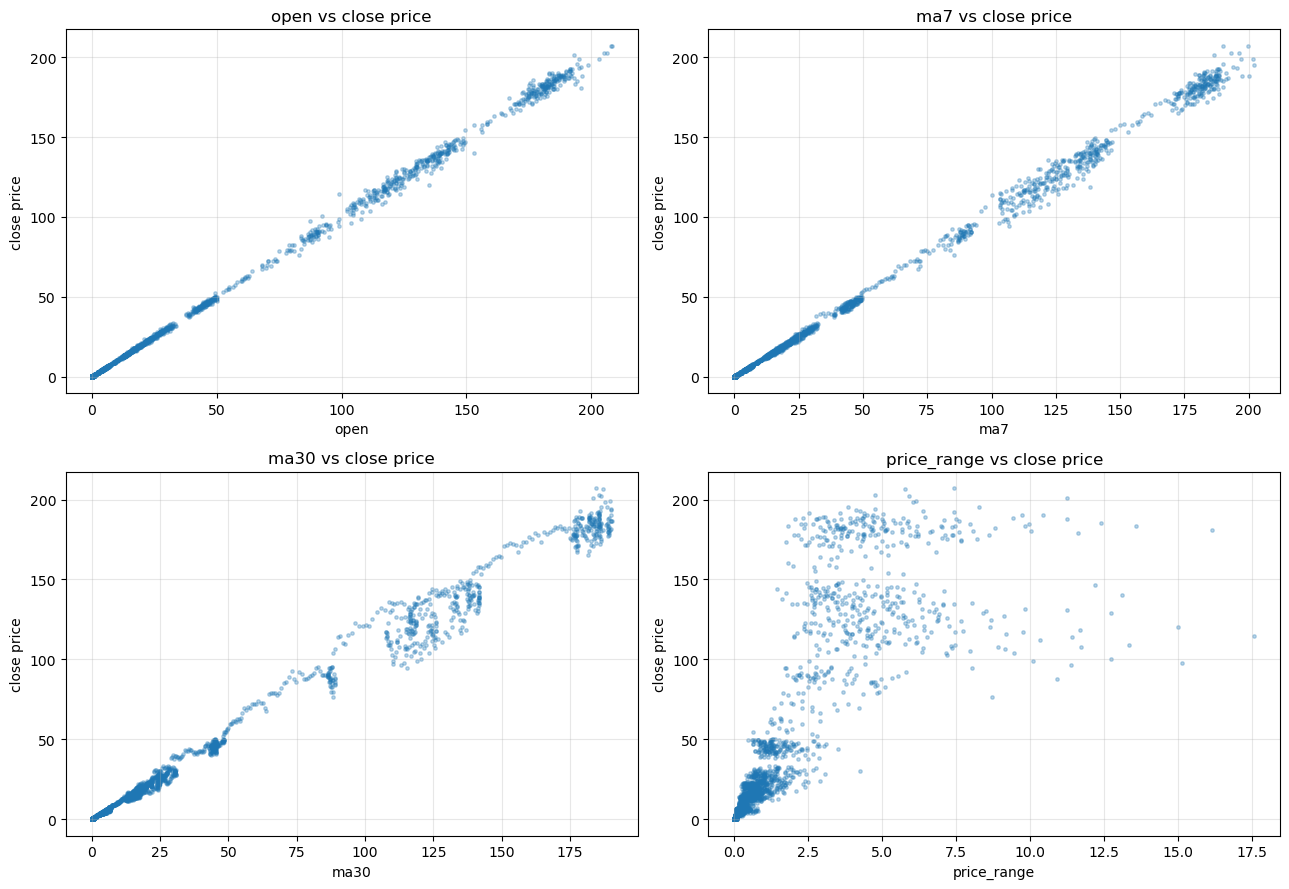

In [28]:
#checking how open, ma7, ma30 and price_range relate to close price
top_feats = ['open', 'ma7', 'ma30', 'price_range']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, feat in enumerate(top_feats):
    axes[i].scatter(df[feat], df['close'], alpha=0.3, s=6)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('close price')
    axes[i].set_title(feat + ' vs close price')
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Linear Regression Predicting Close Price**

Using Linear Regression to predict NVIDIA's closing price based on features like open price, moving averages and daily return

The model learns a straight line relationship between the inputs and the closing price

In [29]:
#machine learning model linear regression
features = ['open', 'volume', 'price_range', 'ma7', 'ma30', 'daily_return']
target   = 'close'
X = df[features]
y = df[target]
#80/20 split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
#scaling the features between 0 and 1
scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('training samples:', len(X_train))
print('testing samples :', len(X_test))

training samples: 5454
testing samples : 1364


In [30]:
#Training the model and checking results
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)
y_pred_lr = lr_model.predict(X_test_sc)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = np.mean(np.abs(y_test - y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
print('linear regression results')
print('rmse :', round(rmse_lr, 4))
print('mae  :', round(mae_lr, 4))
print('r2   :', round(r2_lr, 4))
print('\nr2 close to 1 means the model fits well')

linear regression results
rmse : 2.0537
mae  : 1.2145
r2   : 0.9989

r2 close to 1 means the model fits well


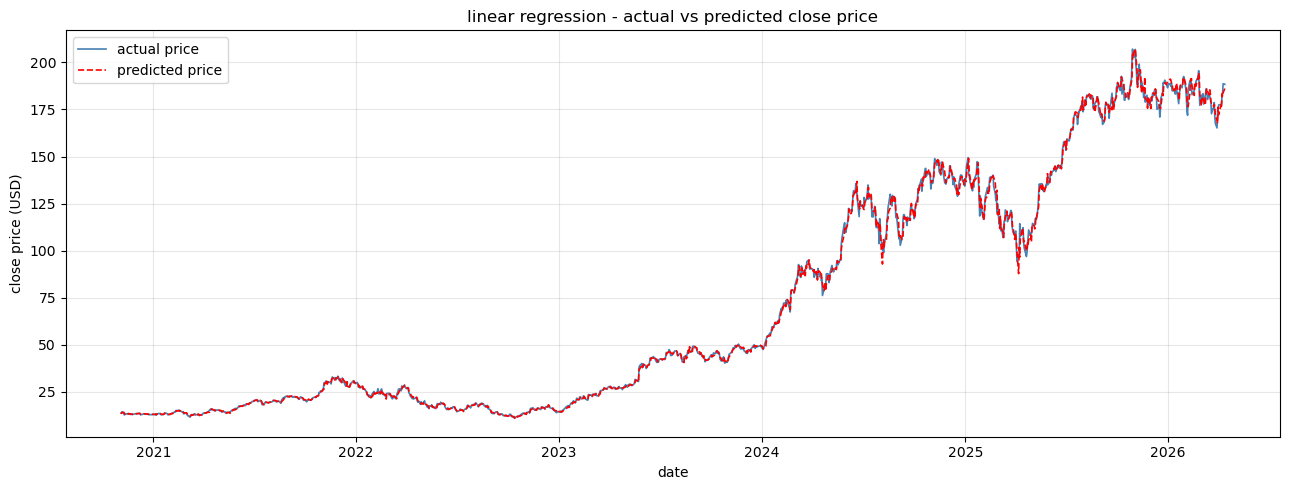


feature coefficients:
     feature  coefficient
        open    12.152558
         ma7     2.709926
daily_return     0.481409
      volume     0.015711
        ma30    -0.185970
 price_range    -0.330215


In [31]:
#Plotting the actual vs predicted close price on the test set
test_dates = df['date'].iloc[len(X_train):].values
plt.figure(figsize=(13, 5))
plt.plot(test_dates, y_test.values,  color='steelblue', linewidth=1.2, label='actual price')
plt.plot(test_dates, y_pred_lr,      color='red',       linewidth=1.2, label='predicted price', linestyle='--')
plt.xlabel('date')
plt.ylabel('close price (USD)')
plt.title('linear regression - actual vs predicted close price')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#feature_coefficients
coef_df = pd.DataFrame({'feature': features, 'coefficient': lr_model.coef_})
coef_df = coef_df.sort_values('coefficient', ascending=False)
print('\nfeature coefficients:')
print(coef_df.to_string(index=False))

**Decision Tree Regression**

Decision Tree splits the data into branches based on conditions on the features
Unlike Linear Regression, it can capture non-linear patterns in the stock price  
We limit the depth to 6 so it doesn't memorize the training data (overfitting)

In [32]:
#decision tree regressor
y_scaler = MinMaxScaler()
y_train_sc = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_sc  = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

#max_depth=6 to avoid overfitting
dt_model = DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=42)
dt_model.fit(X_train_sc, y_train_sc)
y_pred_dt_sc = dt_model.predict(X_test_sc)
y_pred_dt = y_scaler.inverse_transform(y_pred_dt_sc.reshape(-1, 1)).ravel()
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt  = np.mean(np.abs(y_test - y_pred_dt))
r2_dt   = r2_score(y_test, y_pred_dt)

print('decision tree results')
print('rmse :', round(rmse_dt, 4))
print('mae  :', round(mae_dt, 4))
print('r2   :', round(r2_dt, 4))

decision tree results
rmse : 84.3112
mae  : 57.7482
r2   : -0.8774


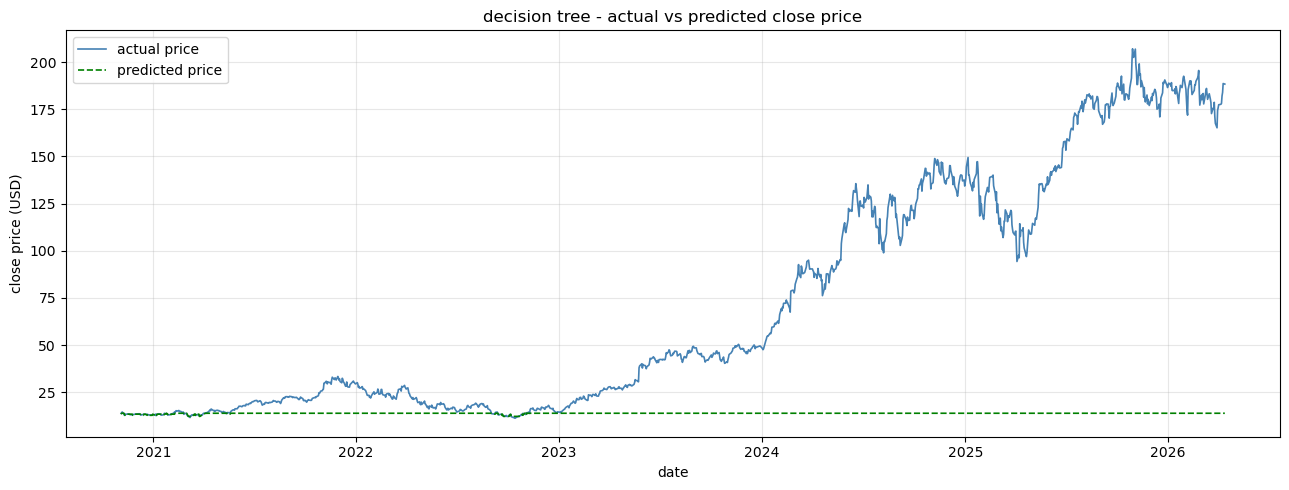

In [33]:
#actual vs predicted for decision tree
plt.figure(figsize=(13, 5))
plt.plot(test_dates, y_test.values, color='steelblue', linewidth=1.2, label='actual price')
plt.plot(test_dates, y_pred_dt,     color='green',     linewidth=1.2, label='predicted price', linestyle='--')
plt.xlabel('date')
plt.ylabel('close price (USD)')
plt.title('decision tree - actual vs predicted close price')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

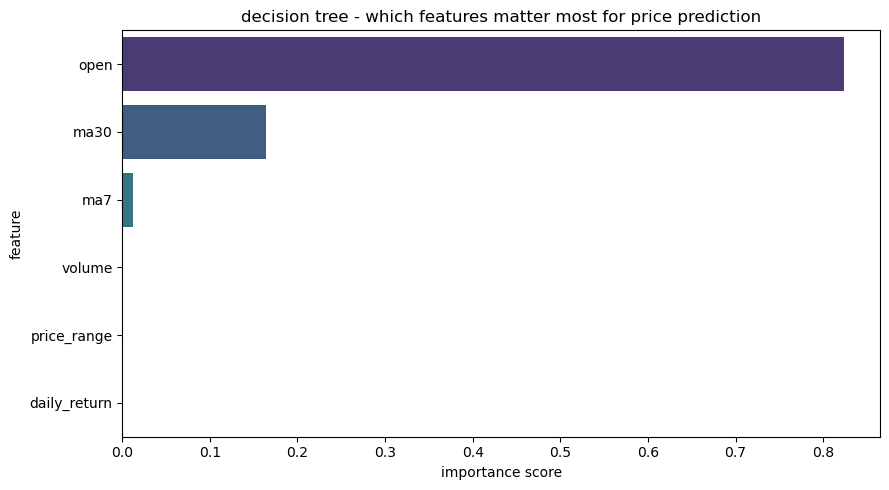

In [34]:
#feature importance from decision tree
imp_df = pd.DataFrame({'feature': features, 'importance': dt_model.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(x='importance', y='feature', data=imp_df, palette='viridis')
plt.title('decision tree - which features matter most for price prediction')
plt.xlabel('importance score')
plt.tight_layout()
plt.show()

**Model Comparison**

            model    rmse     mae  r2_score
linear regression  2.0537  1.2145    0.9989
    decision tree 84.3112 57.7482   -0.8774


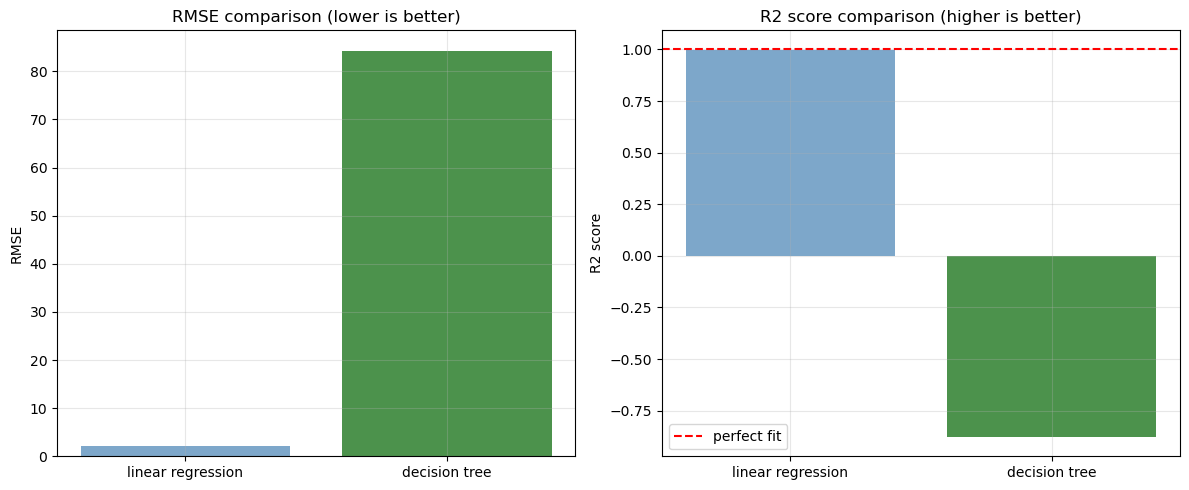

In [42]:
#comparing linear regression and decision tree side by side
comparison_df = pd.DataFrame({
    'model'   : ['linear regression', 'decision tree'],
    'rmse'    : [round(rmse_lr, 4), round(rmse_dt, 4)],
    'mae'     : [round(mae_lr, 4),  round(mae_dt, 4)],
    'r2_score': [round(r2_lr, 4),   round(r2_dt, 4)]
})
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['linear regression', 'decision tree'], [rmse_lr, rmse_dt],
            color=['steelblue', 'darkgreen'], alpha=0.7)
axes[0].set_title('RMSE comparison (lower is better)')
axes[0].set_ylabel('RMSE')
axes[0].grid(alpha=0.3)

axes[1].bar(['linear regression', 'decision tree'], [r2_lr, r2_dt],
            color=['steelblue', 'darkgreen'], alpha=0.7)
axes[1].set_title('R2 score comparison (higher is better)')
axes[1].set_ylabel('R2 score')
axes[1].axhline(y=1.0, color='red', linestyle='--', label='perfect fit')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**K-Means Clustering to identify Market Behavior Patterns**

K-Means groups similar trading days together based on daily return, price range and volume 

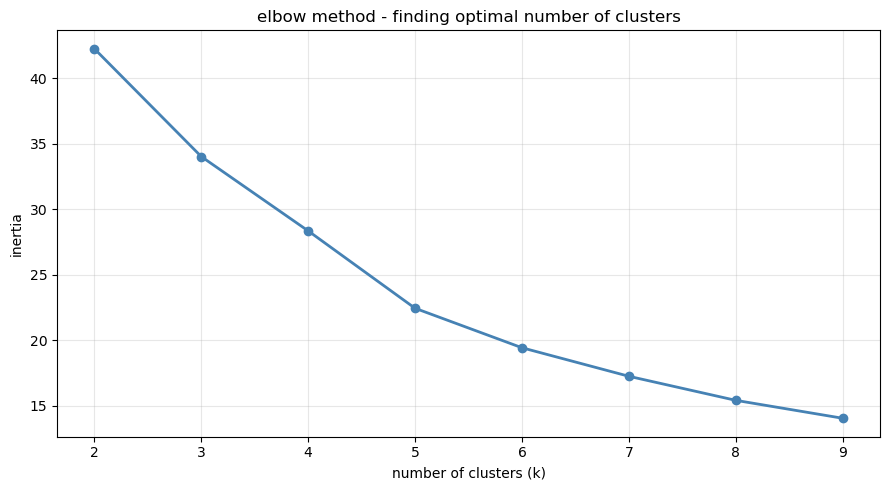

In [36]:
#clustering stock days by daily return, price range and volume
cluster_df = df[['daily_return', 'price_range', 'volume']].copy()
cluster_df.dropna(inplace=True)
scaler2 = MinMaxScaler()
cluster_scaled = scaler2.fit_transform(cluster_df)
#elbow method run kmeans for different k values and plot inertia
inertia_vals = []
k_range = range(2, 10)
for k in k_range:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(cluster_scaled)
    inertia_vals.append(km_temp.inertia_)
plt.figure(figsize=(9, 5))
plt.plot(k_range, inertia_vals, marker='o', color='steelblue', linewidth=2)
plt.xlabel('number of clusters (k)')
plt.ylabel('inertia')
plt.title('elbow method - finding optimal number of clusters')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

k-means silhouette score (k=4): 0.3978
silhouette score closer to 1.0 means clusters are well separated


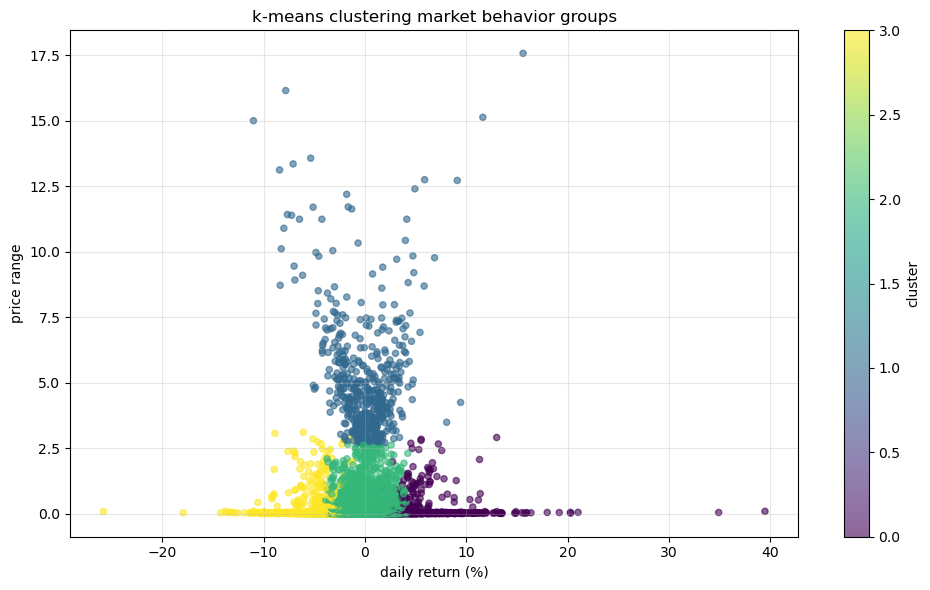

In [37]:
#fitting kmeans with k=4 representing 4 market behaviors
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df['cluster_km'] = kmeans.fit_predict(cluster_scaled)
sil_score_km = silhouette_score(cluster_scaled, cluster_df['cluster_km'])
print(f'k-means silhouette score (k=4): {sil_score_km:.4f}')
print('silhouette score closer to 1.0 means clusters are well separated')
plt.figure(figsize=(10, 6))
scatter = plt.scatter(cluster_df['daily_return'], cluster_df['price_range'],
                     c=cluster_df['cluster_km'], cmap='viridis', s=20, alpha=0.6)
plt.colorbar(scatter, label='cluster')
plt.xlabel('daily return (%)')
plt.ylabel('price range')
plt.title('k-means clustering market behavior groups')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
#avg characteristics per cluster
cluster_summary = cluster_df.groupby('cluster_km')[['daily_return', 'price_range', 'volume']].mean()
print('average values per cluster (market behavior groups):')
print(cluster_summary.round(4))

average values per cluster (market behavior groups):
            daily_return  price_range        volume
cluster_km                                         
0                 4.7585       0.1448  1.059344e+09
1                -0.0115       5.1784  2.805124e+08
2                 0.1373       0.1973  4.260847e+08
3                -3.8698       0.1662  9.612671e+08


**DBSCAN Clustering**

DBSCAN is different from K-Means because we don't need to tell it how many clusters to make

It finds clusters based on density and also marks outlier/unusual trading days as noise

This is useful for finding abnormal market days

In [39]:
# no need to specify k it finds clusters on its own
dbscan = DBSCAN(eps=0.15, min_samples=15)
db_labels = dbscan.fit_predict(cluster_scaled)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = list(db_labels).count(-1)
print('clusters found by dbscan:', n_clusters_db)
print('unusual/outlier trading days:', n_noise, '(', round(n_noise/len(db_labels)*100, 1), '% of data)')

clusters found by dbscan: 1
unusual/outlier trading days: 8 ( 0.1 % of data)


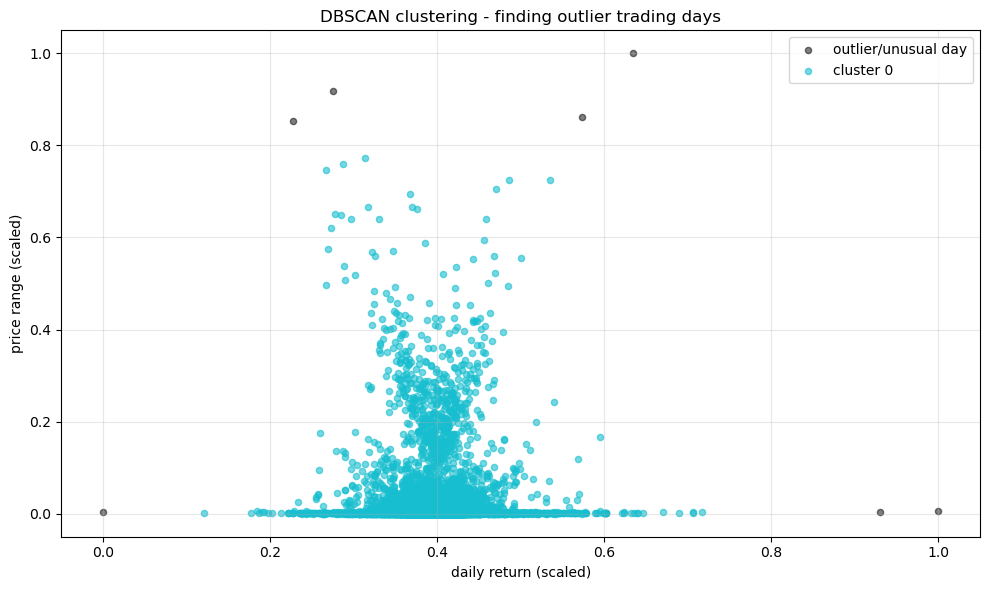

In [40]:
#Plotting dbscan black points are outlier trading days
plt.figure(figsize=(10, 6))
unique_labels = sorted(set(db_labels))
palette = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))
for idx, label in enumerate(unique_labels):
    mask = db_labels == label
    if label == -1:
        plt.scatter(cluster_scaled[mask, 0], cluster_scaled[mask, 1],
                    c='black', s=20, alpha=0.5, label='outlier/unusual day')
    else:
        plt.scatter(cluster_scaled[mask, 0], cluster_scaled[mask, 1],
                    c=[palette[idx]], s=20, alpha=0.6, label=f'cluster {label}')
plt.xlabel('daily return (scaled)')
plt.ylabel('price range (scaled)')
plt.title('DBSCAN clustering - finding outlier trading days')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Summary**

In [41]:
#Final_results_summary
print('FINAL PROJECT RESULTS SUMMARY')
print('=' * 45)
print('dataset       : NVIDIA (NVDA) Historical Stock')
print('total rows    :', df.shape[0])
print('date range    :', str(df['date'].min().date()), 'to', str(df['date'].max().date()))
print()
print('   Prediction Models ')
print('linear regression  ->  rmse:', round(rmse_lr, 4), '  r2:', round(r2_lr, 4))
print('decision tree      ->  rmse:', round(rmse_dt, 4), '  r2:', round(r2_dt, 4))
print()
print('   Clustering Results   ')
print('k-means silhouette score:', round(sil_score_km, 4))
print('dbscan clusters found   :', n_clusters_db)
print('dbscan outliers found   :', n_noise)
print()
print('Best model: linear regression _ higher r2_score')

FINAL PROJECT RESULTS SUMMARY
dataset       : NVIDIA (NVDA) Historical Stock
total rows    : 6818
date range    : 1999-03-05 to 2026-04-13

   Prediction Models 
linear regression  ->  rmse: 2.0537   r2: 0.9989
decision tree      ->  rmse: 84.3112   r2: -0.8774

   Clustering Results   
k-means silhouette score: 0.3978
dbscan clusters found   : 1
dbscan outliers found   : 8

Best model: linear regression _ higher r2_score
